# Tutoría + Preparación de Proyecto (sesión de hoy)

Hoy vamos a dejar **todo preparado** para que puedas trabajar solo durante los próximos días.

Al terminar la sesión, cada persona debe salir con:
- Un **dataset elegido** (y validado) que sea *suficientemente sucio*.
- 3–5 **preguntas** claras.
- Una **estructura de proyecto** creada.
- Un pipeline mínimo: **raw → clean → features → viz**.

**Entrega final (lunes):** repo/zip con README + notebook ejecutable + código modular en `src/`.

## Entregables (lo que espero el lunes)

### Mínimo para aprobar (si entregas esto, apruebas)
- `README.md` con objetivo, dataset, preguntas, pasos y conclusiones.
- `notebooks/eda.ipynb` que corre de principio a fin.
- Carpeta `src/` con **al menos 3 funciones reales** (carga, limpieza, visualización o features).
- 4–6 gráficos con intención.
- 3 conclusiones (bullet points) basadas en evidencia.

### Para nota
- Pipeline más limpio (notebook orquestando, funciones en `src/`).
- Validaciones simples (asserts).
- Gráficos bien presentados (títulos, labels, lectura clara).
- Transformaciones no triviales (fechas, categorías, outliers, pivots/agrupaciones).


## Checklist genérico para elegir dataset (sin hacer EDA)

**Antes de descargar, solo con la preview / descripción:**
- +1.000 filas
- 5+ columnas
- Mezcla numéricas y categóricas
- Columnas entendibles y descritas
- Puedes imaginar 4–5 preguntas interesantes

**Señales de “dataset sucio” (queremos esto):**
- Tipos sospechosos (números como texto, fechas como texto)
- Missing values
- Categorías inconsistentes ("male", "Male", "M")
- Duplicados o IDs raros
- Outliers plausibles (valores extremos)
- Nombres de columnas malos (espacios, mayúsculas mezcladas)

**Evitar:**
- Dataset demasiado pequeño
- Dataset “toy”
- Dataset sin contexto (no entiendes qué mide)


## Actividad (5 minutos)

Escribe en tu propio documento:
- Link del dataset
- 1 frase: objetivo del proyecto
- 3–5 preguntas (bullets)
- 3 problemas de datos que sospechas que tendrás que arreglar


## Estructura recomendada del proyecto

Regla: el notebook **explica** y **orquesta**. El código repetible va a `src/`.

Estructura mínima:

```
project/
├── main.py
├── data/
│   ├── raw/
│   └── processed/
├── notebooks/
│   └── eda.ipynb
├── src/
│   ├── init.py
│   ├── io.py
│   ├── cleaning.py
│   ├── features.py
│   ├── viz.py
│   └── utils.py
├── README.md
└── requirements.txt
```


## Plantilla de README

### 1) Objetivo
- ¿Qué quieres entender o explicar con este dataset?

### 2) Dataset
- Fuente:
- Nº filas/columnas:
- Variables clave:

### 3) Preguntas
- Q1:
- Q2:
- Q3:
- (opcionales)

### 4) Data issues & fixes
- Problema → Solución
- Problema → Solución
- Problema → Solución

### 5) Pipeline
- raw → clean → features → viz → (export opcional a `data/processed/`)

### 6) Hallazgos
- Insight 1 (con referencia a gráfico)
- Insight 2
- Insight 3

### 7) Estructura del proyecto
- `src/` contiene funciones reutilizables (`io`, `cleaning`, `features`, `viz`)
- `main.py` ejecuta el pipeline end-to-end

### 8) Cómo ejecutar
- `pip install -r requirements.txt`
- Ejecutar pipeline: `python main.py`
- (Opcional) Abrir y ejecutar: `notebooks/eda.ipynb`

---
# Demo (con dataset sucio generado)

Para practicar ahora si todavía no tienes un ficheros externo, vamos a generar un CSV “sucio” y construir el pipeline.

Se aplicará un esquema parecido a un dataset externo.


In [10]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

# Project root for the demo (current working directory)
ROOT = Path.cwd() / 'project_demo'
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
NOTEBOOKS = ROOT / 'notebooks'
SRC = ROOT / 'src'
csv_path = DATA_RAW / "demo_dirty.csv"

for p in [DATA_RAW, DATA_PROCESSED, NOTEBOOKS, SRC]:
    p.mkdir(parents=True, exist_ok=True)

ROOT

PosixPath('/Users/nicostan/Downloads/vscode/project_demo')

## 1) Crear un CSV sucio (solo para la demo)

Incluye problemas típicos:
- fechas como texto con formatos mezclados
- números como texto con separadores
- categorías inconsistentes
- missing values
- duplicados


In [11]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 800

cities = ["Madrid", "Barcelona", "Valencia", "Sevilla"]
channels = ["Online", "Store", "store", "ONLINE"]
products = ["A", "B", "C", "D"]

# Build a dirty Date column with variability across months + mixed formats
start = pd.Timestamp("2024-01-01")
end = pd.Timestamp("2024-10-31")
date_range = pd.date_range(start, end, freq="D")

# rng.choice returns numpy.datetime64 -> convert to pandas Timestamp before strftime
dates = rng.choice(date_range.to_numpy(), size=n, replace=True)

formats = [
    lambda ts: ts.strftime("%Y-%m-%d"),   # 2024-03-10
    lambda ts: ts.strftime("%d/%m/%Y"),   # 10/03/2024
    lambda ts: ts.strftime("%Y/%m/%d"),   # 2024/03/10
    lambda ts: ts.strftime("%b %d, %Y"),  # Mar 10, 2024
]

date_str = []
for d in dates:
    if rng.random() < 0.05:
        date_str.append(None)  # inject missing
    else:
        ts = pd.Timestamp(d)   # convert numpy.datetime64 -> Timestamp
        f = rng.choice(formats)
        date_str.append(f(ts))

df_dirty = pd.DataFrame({
    "Invoice ID": [f"INV-{1000+i}" for i in range(n)],
    "City": rng.choice(cities, size=n, replace=True),
    "Channel": rng.choice(channels, size=n, replace=True),
    "Product line": rng.choice(products, size=n, replace=True),
    "Unit price": rng.normal(25, 8, size=n).round(2),
    "Quantity": rng.integers(1, 10, size=n),
    "Date": date_str,
    "Rating": rng.normal(7.0, 1.2, size=n).round(1),
})

# Introduce numeric-as-text issues in Unit price (commas, strings)
df_dirty["Unit price"] = df_dirty["Unit price"].astype(str)
idx_comma = rng.choice(df_dirty.index, size=40, replace=False)
df_dirty.loc[idx_comma, "Unit price"] = df_dirty.loc[idx_comma, "Unit price"].str.replace(".", ",", regex=False)

# Missing values in Rating
idx_nan = rng.choice(df_dirty.index, size=40, replace=False)
df_dirty.loc[idx_nan, "Rating"] = np.nan

# Create Total from dirty Unit price (still stored as text with possible commas)
unit_price_num = pd.to_numeric(df_dirty["Unit price"].str.replace(",", ".", regex=False), errors="coerce")
df_dirty["Total"] = (df_dirty["Quantity"] * unit_price_num).round(2).astype(str)

# Make some Totals use comma decimal separator too
idx_total_comma = rng.choice(df_dirty.index, size=25, replace=False)
df_dirty.loc[idx_total_comma, "Total"] = df_dirty.loc[idx_total_comma, "Total"].str.replace(".", ",", regex=False)

# Add duplicate rows
dup_rows = df_dirty.sample(15, random_state=1)
df_dirty = pd.concat([df_dirty, dup_rows], ignore_index=True)

# Save to CSV (uses csv_path defined earlier)
df_dirty.to_csv(csv_path, index=False)

csv_path, df_dirty.shape

(PosixPath('/Users/nicostan/Downloads/vscode/project_demo/data/raw/demo_dirty.csv'),
 (815, 9))

## 2) QC rápido (lo mínimo que quiero ver en vuestro notebook)

- `head()`
- `shape`
- `info()`
- nulos
- duplicados

La idea: detectar problemas sin perder 30 minutos.

In [12]:
df = pd.read_csv(csv_path)

display(df.head())
print('shape:', df.shape)
print('\ninfo:')
display(df.info())

na_rate = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
dup_count = df.duplicated().sum()

print('\nMissing %:')
display(na_rate)
print('\nDuplicated rows:', int(dup_count))

,Invoice ID,City,Channel,Product line,Unit price,Quantity,Date,Rating,Total
0,INV-1000,Sevilla,store,C,25.92,7,2024/01/28,5.8,181.44
1,INV-1001,Sevilla,store,A,26.3,3,"Aug 24, 2024",5.2,78.9
2,INV-1002,Valencia,Online,B,33.31,3,18/07/2024,8.6,99.93
3,INV-1003,Sevilla,Online,C,16.31,2,"May 13, 2024",9.9,32.62
4,INV-1004,Madrid,ONLINE,D,"26,41",1,"May 12, 2024",6.4,26.41


shape: (815, 9)

info:
<class 'pandas.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Invoice ID    815 non-null    str    
 1   City          815 non-null    str    
 2   Channel       815 non-null    str    
 3   Product line  815 non-null    str    
 4   Unit price    815 non-null    str    
 5   Quantity      815 non-null    int64  
 6   Date          770 non-null    str    
 7   Rating        775 non-null    float64
 8   Total         815 non-null    str    
dtypes: float64(1), int64(1), str(7)
memory usage: 57.4 KB


None


Missing %:


Date            5.52
Rating          4.91
Invoice ID      0.00
City            0.00
Channel         0.00
Product line    0.00
Unit price      0.00
Quantity        0.00
Total           0.00
dtype: float64


Duplicated rows: 15


In [13]:
# Longer QC: cardinality + rare categories (categorical issues)
import pandas as pd

def qc_cardinality_and_categories(df: pd.DataFrame, top_n: int = 15, rare_threshold: float = 0.02):
    """
    Prints quick signals for categorical columns:
    - cardinality (nunique)
    - most common categories
    - rare categories (below rare_threshold share)
    """
    n = len(df)
    print(f"Rows: {n:,} | Columns: {df.shape[1]}\n")

    # Candidate categorical columns: object/string/category + low-ish unique ratio
    cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    if not cat_cols:
        print("No categorical columns detected (object/string/category).")
        return

    summary = []
    for col in cat_cols:
        nunique = df[col].nunique(dropna=True)
        missing_pct = df[col].isna().mean() * 100
        unique_ratio = nunique / max(n, 1)
        summary.append((col, nunique, unique_ratio, missing_pct))

    summary_df = (
        pd.DataFrame(summary, columns=["column", "n_unique", "unique_ratio", "missing_%"])
        .sort_values(["unique_ratio", "n_unique"], ascending=[True, True])
    )

    print("Categorical columns summary (lower unique_ratio usually = more 'categorical'):")
    display(summary_df)

    print("\nDetails:")
    for col, nunique, unique_ratio, missing_pct in summary_df.itertuples(index=False):
        print(f"\n--- {col} ---")
        print(f"n_unique={nunique} | unique_ratio={unique_ratio:.4f} | missing={missing_pct:.2f}%")

        vc = df[col].value_counts(dropna=False)
        print(f"\nTop {top_n} value_counts:")
        display(vc.head(top_n))

        # Rare categories (excluding NaN) by share
        vc_no_na = df[col].value_counts(dropna=True)
        shares = (vc_no_na / vc_no_na.sum())
        rare = shares[shares < rare_threshold]

        if len(rare) > 0:
            print(f"\nRare categories (<{rare_threshold*100:.1f}% of non-missing):")
            display(pd.DataFrame({"count": vc_no_na[rare.index], "share": rare}).sort_values("share"))
        else:
            print(f"\nNo rare categories below {rare_threshold*100:.1f}% threshold.")

# Usage:
qc_cardinality_and_categories(df)

Rows: 815 | Columns: 9

Categorical columns summary (lower unique_ratio usually = more 'categorical'):


,column,n_unique,unique_ratio,missing_%
1,City,4,0.004908,0.000000
2,Channel,4,0.004908,0.000000
3,Product line,4,0.004908,0.000000
5,Date,563,0.690798,5.521472
4,Unit price,704,0.863804,0.000000
6,Total,787,0.965644,0.000000
0,Invoice ID,800,0.981595,0.000000



Details:

--- City ---
n_unique=4 | unique_ratio=0.0049 | missing=0.00%

Top 15 value_counts:


City
Madrid       217
Sevilla      208
Valencia     207
Barcelona    183
Name: count, dtype: int64


No rare categories below 2.0% threshold.

--- Channel ---
n_unique=4 | unique_ratio=0.0049 | missing=0.00%

Top 15 value_counts:


...

,count,share
Total,,
24.43,1,0.001227
84.48,1,0.001227
29.37,1,0.001227
33.78,1,0.001227
154.65,1,0.001227
...,...,...
134.72,2,0.002454
61.26,2,0.002454
21.01,2,0.002454



--- Invoice ID ---
n_unique=800 | unique_ratio=0.9816 | missing=0.00%

Top 15 value_counts:


Invoice ID
INV-1008    2
INV-1084    2
INV-1111    2
INV-1175    2
INV-1242    2
INV-1255    2
INV-1289    2
INV-1349    2
INV-1430    2
INV-1510    2
INV-1540    2
INV-1642    2
INV-1703    2
INV-1735    2
INV-1764    2
Name: count, dtype: int64


Rare categories (<2.0% of non-missing):


,count,share
Invoice ID,,
INV-1392,1,0.001227
INV-1522,1,0.001227
INV-1523,1,0.001227
INV-1524,1,0.001227
INV-1525,1,0.001227
...,...,...
INV-1642,2,0.002454
INV-1735,2,0.002454
INV-1764,2,0.002454


## 3) Limpieza mínima (2–3 fixes típicos)

Ejemplos de fixes que cuentan como “trabajar el dataset”:
- normalizar strings (mayúsculas/minúsculas, espacios)
- convertir números que vienen como texto
- parsear fechas
- decidir qué hacer con nulos (drop, imputación simple, etc.)
- eliminar duplicados


In [14]:
df_clean = df.copy()

# Standardize column names (example)
df_clean.columns = [c.strip().lower().replace(' ', '_') for c in df_clean.columns]

# Standardize categorical values
df_clean['channel'] = df_clean['channel'].astype('string').str.strip().str.lower().replace({'online': 'online', 'store': 'store'})

# Convert numeric-like text with comma decimal separators
for col in ['unit_price', 'total']:
    df_clean[col] = (
        df_clean[col]
        .astype('string')
        .str.replace(',', '.', regex=False)
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Parse dates robustly
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce', dayfirst=True)

# Drop duplicates
df_clean = df_clean.drop_duplicates()

print('after cleaning shape:', df_clean.shape)
display(df_clean.head())

print('\nMissing % after:')
display((df_clean.isna().mean().sort_values(ascending=False) * 100).round(2))

after cleaning shape: (800, 9)


/var/folders/5v/dc6514ld10d33dy0zgf23r6m0000gn/T/ipykernel_11758/262571511.py:19: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce', dayfirst=True)


,invoice_id,city,channel,product_line,unit_price,quantity,date,rating,total
0,INV-1000,Sevilla,store,C,25.92,7,2024-01-28,5.8,181.44
1,INV-1001,Sevilla,store,A,26.3,3,NaT,5.2,78.9
2,INV-1002,Valencia,online,B,33.31,3,NaT,8.6,99.93
3,INV-1003,Sevilla,online,C,16.31,2,NaT,9.9,32.62
4,INV-1004,Madrid,online,D,26.41,1,NaT,6.4,26.41



Missing % after:


date            77.38
rating           5.00
invoice_id       0.00
city             0.00
channel          0.00
product_line     0.00
unit_price       0.00
quantity         0.00
total            0.00
dtype: float64

## 4) Features mínimas (solo 2–3)

Ejemplos:
- `month`, `weekday`
- `revenue_per_item`
- bins / grupos (`pd.cut`)

No queremos “feature engineering loco”; queremos práctica con Pandas.


In [15]:
df_feat = df_clean.copy()

df_feat['month'] = df_feat['date'].dt.to_period('M').astype('string')
df_feat['weekday'] = df_feat['date'].dt.day_name()
df_feat['revenue_per_item'] = df_feat['total'] / df_feat['quantity']

display(df_feat[['date','month','weekday','quantity','total','revenue_per_item']].head())

,date,month,weekday,quantity,total,revenue_per_item
0,2024-01-28,2024-01,Sunday,7,181.44,25.92
1,NaT,<NA>,NaN,3,78.9,26.3
2,NaT,<NA>,NaN,3,99.93,33.31
3,NaT,<NA>,NaN,2,32.62,16.31
4,NaT,<NA>,NaN,1,26.41,26.41


## 5) Visualización (4–6 gráficos con intención)

Regla práctica:
- 1 gráfico de comparación
- 1 distribución
- 1 relación
- 1 temporal o heatmap (si aplica)

Cada gráfico debe tener:
- título
- ejes claros
- interpretación (1–2 frases)


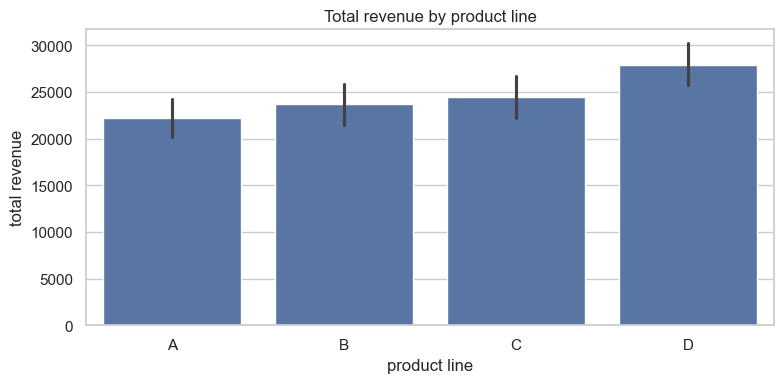

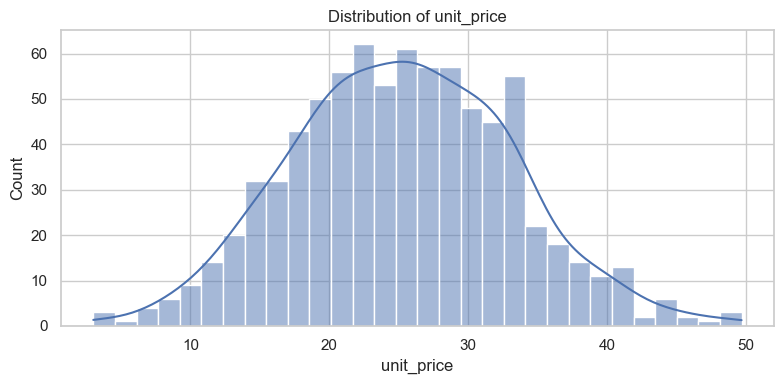

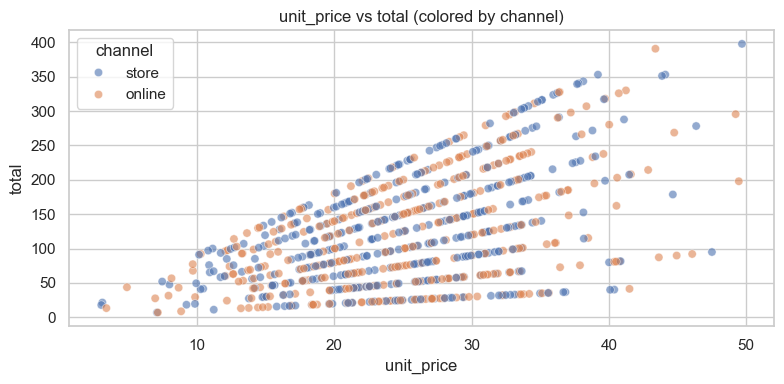

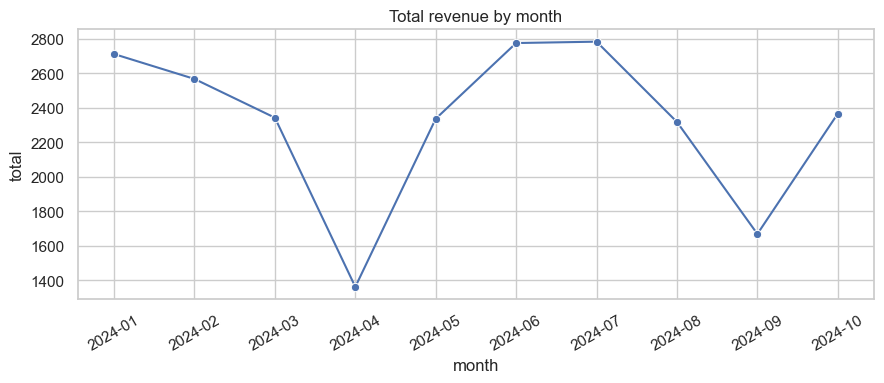

In [16]:
# Comparison: total by product_line
plt.figure(figsize=(8,4))
order = df_feat.groupby('product_line')['total'].sum().sort_values().index
sns.barplot(data=df_feat, x='product_line', y='total', estimator=np.sum, order=order)
plt.title('Total revenue by product line')
plt.xlabel('product line')
plt.ylabel('total revenue')
plt.tight_layout()
plt.show()

# Distribution: unit_price
plt.figure(figsize=(8,4))
sns.histplot(data=df_feat, x='unit_price', bins=30, kde=True)
plt.title('Distribution of unit_price')
plt.tight_layout()
plt.show()

# Relationship: unit_price vs total
plt.figure(figsize=(8,4))
sns.scatterplot(data=df_feat, x='unit_price', y='total', hue='channel', alpha=0.6)
plt.title('unit_price vs total (colored by channel)')
plt.tight_layout()
plt.show()

# Temporal: total by month
month_sum = df_feat.groupby('month', as_index=False)['total'].sum().sort_values('month')
plt.figure(figsize=(9,4))
sns.lineplot(data=month_sum, x='month', y='total', marker='o')
plt.title('Total revenue by month')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6) Modularización mínima (estructura real de proyecto)

La idea: el notebook explica y orquesta el análisis, pero el código repetible va a `src/`.

Estructura mínima que vamos a usar:

- `src/` (paquete)
  - `__init__.py` (marca `src` como paquete)
  - `io.py` (carga/guardado)
  - `cleaning.py` (limpieza)
  - `features.py` (features)
  - `viz.py` (gráficos reutilizables)
  - `utils.py` (validaciones simples)

Además, crearemos un `main.py` en la raíz del proyecto para ejecutar el pipeline de forma reproducible
(sin depender del notebook):

- `main.py` (entrypoint: load → clean → features → export)

Hoy generamos estos archivos automáticamente como plantilla.

In [17]:
from pathlib import Path

# Ensure src folder exists
SRC.mkdir(parents=True, exist_ok=True)

# 0) Make src a package
init_py = SRC / "__init__.py"
init_py.write_text("# src package\n")

# 1) Module paths
io_py = SRC / "io.py"
cleaning_py = SRC / "cleaning.py"
features_py = SRC / "features.py"
viz_py = SRC / "viz.py"
utils_py = SRC / "utils.py"

# 2) Write modules
io_py.write_text("""from pathlib import Path


def load_csv(path: str | Path):
    \"\"\"Load a CSV file into a DataFrame.\"\"\"
    import pandas as pd
    return pd.read_csv(path)
""")

cleaning_py.write_text("""import pandas as pd


def clean(df: pd.DataFrame) -> pd.DataFrame:
    \"\"\"Basic cleaning: column names, categories, numeric parsing, date parsing, duplicates.\"\"\"
    out = df.copy()
    out.columns = [c.strip().lower().replace(' ', '_') for c in out.columns]
    if 'channel' in out.columns:
        out['channel'] = out['channel'].astype('string').str.strip().str.lower()
    for col in ['unit_price', 'total']:
        if col in out.columns:
            out[col] = out[col].astype('string').str.replace(',', '.', regex=False)
            out[col] = pd.to_numeric(out[col], errors='coerce')
    if "date" in out.columns:
        d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=False)
        d2 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
        out["date"] = d1.fillna(d2)
    out = out.drop_duplicates()
    return out
""")

features_py.write_text("""import pandas as pd


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    \"\"\"Create a few basic features (month, weekday, ratios).\"\"\"
    out = df.copy()
    if 'date' in out.columns:
        out['month'] = out['date'].dt.to_period('M').astype('string')
        out['weekday'] = out['date'].dt.day_name()
    if set(['total','quantity']).issubset(out.columns):
        out['revenue_per_item'] = out['total'] / out['quantity']
    return out
""")

viz_py.write_text("""import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def plot_total_by_category(df, category_col='product_line', value_col='total'):
    order = df.groupby(category_col)[value_col].sum().sort_values().index
    plt.figure(figsize=(8,4))
    sns.barplot(data=df, x=category_col, y=value_col, estimator=np.sum, order=order)
    plt.title(f'Total {value_col} by {category_col}')
    plt.tight_layout()
    plt.show()
""")

utils_py.write_text("""def assert_columns(df, required):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing columns: {missing}')
""")

# 3) Create main.py entrypoint at project root
main_py = ROOT / "main.py"
main_py.write_text("""from pathlib import Path

from src.io import load_csv
from src.cleaning import clean
from src.features import build_features


def main():
    root = Path(__file__).resolve().parent
    raw_path = root / "data" / "raw" / "demo_dirty.csv"
    out_path = root / "data" / "processed" / "demo_clean_features.csv"

    df = load_csv(raw_path)
    df = clean(df)
    df = build_features(df)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")


if __name__ == "__main__":
    main()
""")

sorted([p.name for p in SRC.glob("*.py")]), main_py.name

(['__init__.py', 'cleaning.py', 'features.py', 'io.py', 'utils.py', 'viz.py'],
 'main.py')

## 7) Notebook “orquestador”: cómo debería verse el flujo

La idea (para vuestro proyecto):
- importar funciones
- cargar
- limpiar
- features
- visualizar
- conclusiones


/Users/nicostan/Downloads/vscode/project_demo/src/cleaning.py:15: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)


,invoice_id,city,channel,product_line,unit_price,quantity,date,rating,total,month,weekday,revenue_per_item
0,INV-1000,Sevilla,store,C,25.92,7,2024-01-28,5.8,181.44,2024-01,Sunday,25.92
1,INV-1001,Sevilla,store,A,26.3,3,NaT,5.2,78.9,<NA>,NaN,26.3
2,INV-1002,Valencia,online,B,33.31,3,NaT,8.6,99.93,<NA>,NaN,33.31
3,INV-1003,Sevilla,online,C,16.31,2,NaT,9.9,32.62,<NA>,NaN,16.31
4,INV-1004,Madrid,online,D,26.41,1,NaT,6.4,26.41,<NA>,NaN,26.41


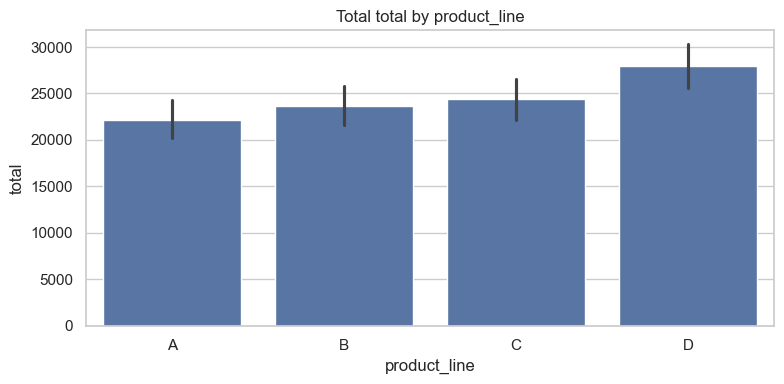

In [18]:
import sys
sys.path.append(str(ROOT))

from src.io import load_csv
from src.cleaning import clean
from src.features import build_features
from src.viz import plot_total_by_category

df0 = load_csv(csv_path)
df1 = clean(df0)
df2 = build_features(df1)

display(df2.head())
plot_total_by_category(df2, category_col='product_line', value_col='total')

## 8) Actividad final (para que cada uno salga con un plan)

Completa esto (en tu README o en una nota):
- Dataset elegido + link
- 3–5 preguntas
- 3–6 issues de datos esperables
- 3 transformaciones que harás sí o sí
- 4–6 gráficos que harás (tipo de gráfico + variables)

Si te falta algo, ese es tu siguiente paso hoy durante la tutoría.


## Presentación del lunes (formato recomendado)

Duración recomendada por alumno: **4 minutos** (+ **1 minuto** transición entre alumnos)

Guion orientativo
- 30s objetivo + dataset
- 90s limpieza / transformaciones (Pandas)
- 90s visualizaciones (2–3) y lectura
- 30s conclusiones + posible siguiente paso
